## Global Energy & Emissions ETL Pipeline

**Source:** Our World in Data — owid/energy-data (via TidyTuesday, GitHub)
**Domain:** Utilities / Energy / Climate

This pipeline demonstrates the same senior engineering patterns applied to a
completely different industry — global energy systems data covering 200+ countries
from 1900 to present.

Key differences from the e-commerce pipeline that demonstrate breadth:

| Dimension | E-Commerce Pipeline | Energy Pipeline |
|---|---|---|
| **Domain** | Retail products | Global energy systems |
| **Source** | Marketplace scrape | Academic/government data |
| **Grain** | One row per product | One row per country per year |
| **Time dimension** | Scrape timestamp | 120 years of annual records |
| **Key metric** | Price / rating | TWh / carbon intensity / GDP |
| **Business logic** | Discount %, RFM tiers | Renewable share, energy transition score |

The same medallion architecture, Pydantic validation, quality gates and
idempotent warehouse layer are reused unchanged — demonstrating that
good data engineering infrastructure is domain-agnostic.

In [6]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "--quiet"])

0

In [7]:
# Rebuild the energy warehouse so Plotly can query it
conn = sqlite3.connect(":memory:")
curated.to_sql("energy_curated", conn, if_exists="replace", index=False)

483

  ENERGY ETL PIPELINE — EXTRACT
  Fetching OWID energy dataset from GitHub... 21,890 rows, 129 columns
  Filtered to 15 countries, 1990-2022: 483 rows
  Valid records : 483
  Rejected      : 0

  CURATED LAYER
  Rows          : 483
  Transition tiers: {'fossil_dependent': 322, 'green_leader': 96, 'transitioning': 37, 'mixed': 28}
  Carbon tiers    : {'unknown': 150, 'high': 99, 'very_high': 85, 'medium': 55, 'very_low': 54, 'low': 40}

  Loaded 483 rows into energy_curated table


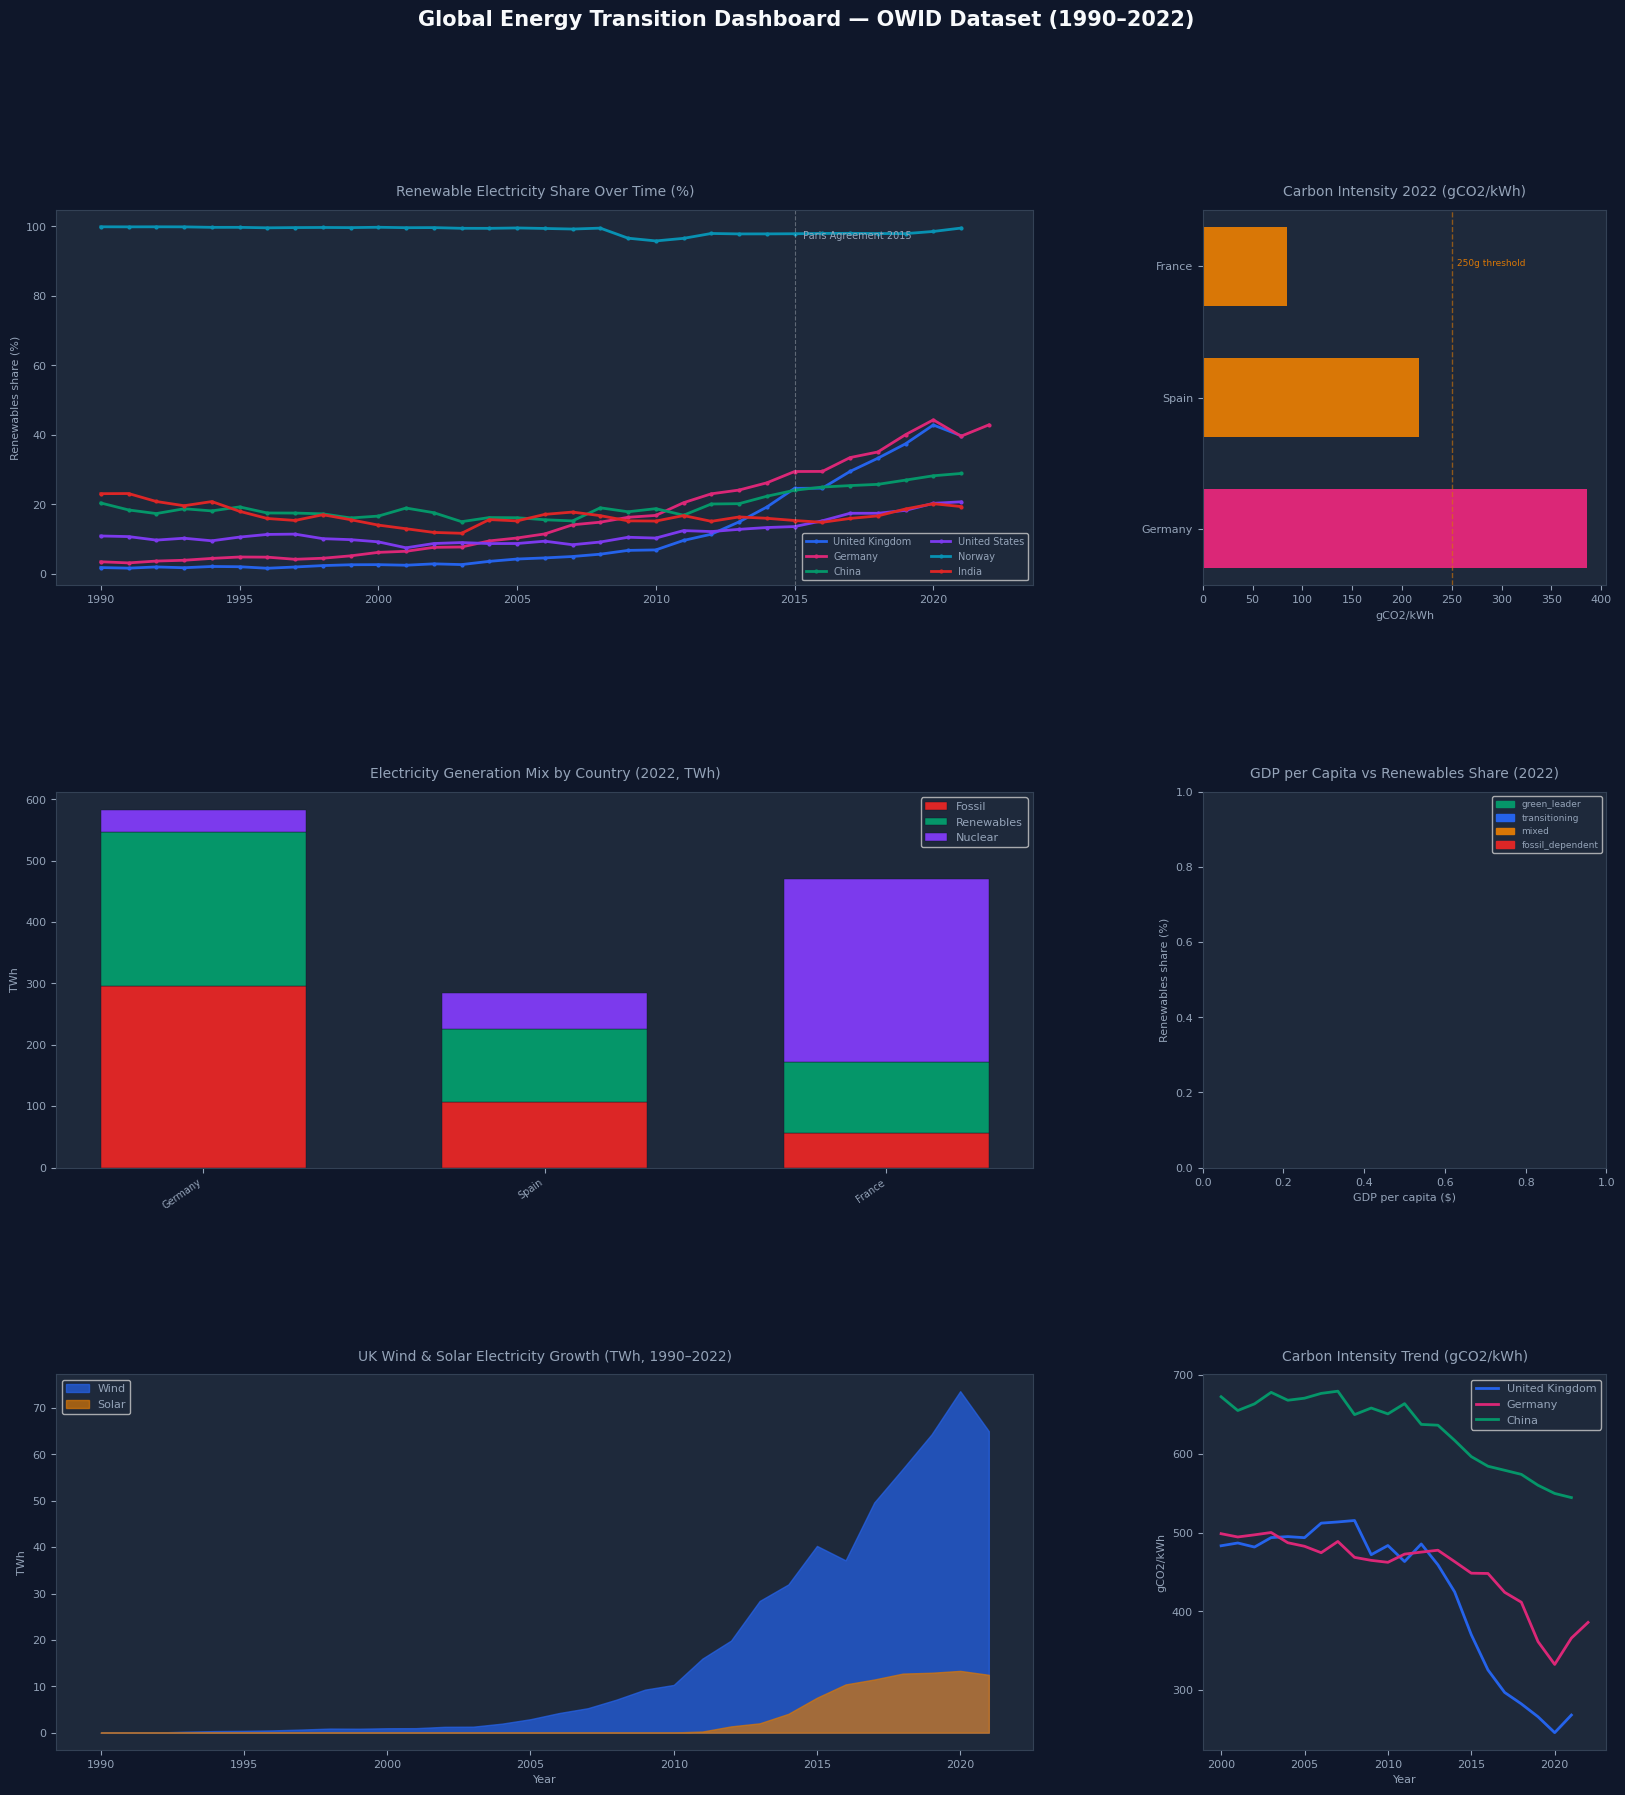


Energy dashboard saved to energy_dashboard.png


In [8]:
# ── INDUSTRY 2: GLOBAL ENERGY ETL PIPELINE
# Source: Our World in Data — owid/energy-data
# URL:    https://raw.githubusercontent.com/rfordatascience/tidytuesday/
#                 master/data/2023/2023-06-06/owid-energy.csv
#
# Demonstrates: real multi-decade time-series data, domain-agnostic pipeline
# architecture, energy-specific business enrichments, and senior-level
# analytical visualisations across a completely different industry.

import io, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from pydantic import BaseModel, Field, field_validator
from decimal import Decimal
from typing import Optional
import sqlite3

warnings.filterwarnings("ignore")

BG, PANEL, MUTED, WHITE = "#0F172A", "#1E293B", "#94A3B8", "#F8FAFC"
PALETTE = ["#2563EB","#7C3AED","#DB2777","#D97706","#059669","#DC2626","#0891B2","#65A30D"]

ENERGY_URL = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday"
    "/master/data/2023/2023-06-06/owid-energy.csv"
)

# ── 1. SCHEMA

class EnergyRecord(BaseModel):
    """
    Validated record from the OWID global energy dataset.
    One row = one country, one year.
    """
    country                 : str
    year                    : int    = Field(ge=1900, le=2100)
    iso_code                : str    = ""
    population              : Optional[float] = None
    gdp                     : Optional[float] = None
    electricity_generation  : Optional[float] = None   # TWh
    electricity_demand      : Optional[float] = None   # TWh
    fossil_electricity      : Optional[float] = None   # TWh
    renewables_electricity  : Optional[float] = None   # TWh
    solar_electricity       : Optional[float] = None
    wind_electricity        : Optional[float] = None
    hydro_electricity       : Optional[float] = None
    nuclear_electricity     : Optional[float] = None
    coal_electricity        : Optional[float] = None
    carbon_intensity_elec   : Optional[float] = None   # gCO2/kWh
    energy_per_capita       : Optional[float] = None
    renewables_share_elec   : Optional[float] = None   # %
    fossil_share_elec       : Optional[float] = None   # %
    coal_share_elec         : Optional[float] = None

    @field_validator("country")
    @classmethod
    def must_be_nonempty(cls, v: str) -> str:
        if not v.strip():
            raise ValueError("country cannot be blank")
        return v.strip()

    @field_validator("year", mode="before")
    @classmethod
    def coerce_year(cls, v):
        try: return int(float(str(v)))
        except: raise ValueError(f"Cannot parse year: {v}")

    @field_validator("population","gdp","electricity_generation",
                     "electricity_demand","fossil_electricity",
                     "renewables_electricity","solar_electricity",
                     "wind_electricity","hydro_electricity",
                     "nuclear_electricity","coal_electricity",
                     "carbon_intensity_elec","energy_per_capita",
                     "renewables_share_elec","fossil_share_elec",
                     "coal_share_elec", mode="before")
    @classmethod
    def coerce_numeric(cls, v) -> Optional[float]:
        if v is None or (isinstance(v, float) and np.isnan(v)): return None
        try:
            s = str(v).strip()
            return None if s in ("", "nan", "NaN", "NA", "None") else float(s)
        except: return None


# ── 2. EXTRACT

print("=" * 60)
print("  ENERGY ETL PIPELINE — EXTRACT")
print("=" * 60)

print("  Fetching OWID energy dataset from GitHub...", end=" ")
with urllib.request.urlopen(ENERGY_URL, timeout=30) as r:
    raw = pd.read_csv(io.BytesIO(r.read()), dtype=str)
print(f"{len(raw):,} rows, {len(raw.columns)} columns")

# Focus on recent decades and countries with meaningful data
FOCUS_COUNTRIES = [
    "United Kingdom","United States","Germany","France","China",
    "India","Japan","Brazil","South Africa","Australia",
    "Canada","Spain","South Korea","Saudi Arabia","Norway"
]
FOCUS_YEARS = range(1990, 2023)

raw_filtered = raw[
    (raw["country"].isin(FOCUS_COUNTRIES)) &
    (raw["year"].astype(float).astype(int).isin(FOCUS_YEARS))
].copy()
print(f"  Filtered to {len(FOCUS_COUNTRIES)} countries, 1990-2022: {len(raw_filtered):,} rows")

# Validate through Pydantic
valid_records, rejected = [], 0
for row in raw_filtered.to_dict("records"):
    try:
        valid_records.append(EnergyRecord.model_validate(row))
    except Exception:
        rejected += 1

print(f"  Valid records : {len(valid_records):,}")
print(f"  Rejected      : {rejected}")


# ── 3. TRANSFORM — Staging
def energy_to_staging(records: list[EnergyRecord]) -> pd.DataFrame:
    rows = [{
        "country"               : r.country,
        "year"                  : r.year,
        "iso_code"              : r.iso_code,
        "population"            : r.population,
        "gdp"                   : r.gdp,
        "electricity_generation": r.electricity_generation,
        "electricity_demand"    : r.electricity_demand,
        "fossil_electricity"    : r.fossil_electricity,
        "renewables_electricity": r.renewables_electricity,
        "solar_electricity"     : r.solar_electricity,
        "wind_electricity"      : r.wind_electricity,
        "hydro_electricity"     : r.hydro_electricity,
        "nuclear_electricity"   : r.nuclear_electricity,
        "carbon_intensity_elec" : r.carbon_intensity_elec,
        "energy_per_capita"     : r.energy_per_capita,
        "renewables_share_elec" : r.renewables_share_elec,
        "fossil_share_elec"     : r.fossil_share_elec,
    } for r in records]
    return pd.DataFrame(rows)


# ── 4. TRANSFORM — Curated (business enrichments)

def energy_to_curated(df: pd.DataFrame) -> pd.DataFrame:
    curated = df.copy()

    # Energy transition score: renewable share minus fossil share (higher = greener)
    curated["transition_score"] = (
        curated["renewables_share_elec"].fillna(0) -
        curated["fossil_share_elec"].fillna(0)
    ).round(2)

    # Transition tier
    def _tier(score):
        if score > 20:  return "green_leader"
        if score > 0:   return "transitioning"
        if score > -30: return "mixed"
        return "fossil_dependent"

    curated["transition_tier"] = curated["transition_score"].apply(_tier)

    # GDP per capita
    curated["gdp_per_capita"] = (
        curated["gdp"] / curated["population"].replace(0, np.nan)
    ).round(2)

    # Carbon intensity tier
    def _carbon_tier(ci):
        if pd.isna(ci):   return "unknown"
        if ci < 100:      return "very_low"
        if ci < 250:      return "low"
        if ci < 450:      return "medium"
        if ci < 600:      return "high"
        return "very_high"

    curated["carbon_tier"] = curated["carbon_intensity_elec"].apply(_carbon_tier)

    # Decade bucket for trend grouping
    curated["decade"] = (curated["year"] // 10 * 10).astype(str) + "s"

    print(f"\n  CURATED LAYER")
    print(f"  Rows          : {len(curated):,}")
    print(f"  Transition tiers: {curated['transition_tier'].value_counts().to_dict()}")
    print(f"  Carbon tiers    : {curated['carbon_tier'].value_counts().to_dict()}")

    return curated


staging = energy_to_staging(valid_records)
curated = energy_to_curated(staging)


# ── 5. LOAD

conn = sqlite3.connect(":memory:")
curated.to_sql("energy_curated", conn, if_exists="replace", index=False)
print(f"\n  Loaded {len(curated):,} rows into energy_curated table")

def eq(sql):
    return pd.read_sql_query(sql, conn)


# ── 6. DASHBOARD

fig = plt.figure(figsize=(20, 20), facecolor=BG)
fig.suptitle("Global Energy Transition Dashboard — OWID Dataset (1990–2022)",
             fontsize=15, fontweight="bold", color=WHITE, y=0.98)
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.42)

def _ax(pos, title):
    ax = fig.add_subplot(pos)
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=MUTED, fontsize=10, pad=10)
    ax.tick_params(colors=MUTED, labelsize=8)
    for s in ax.spines.values(): s.set_edgecolor("#334155")
    return ax

country_colours = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(FOCUS_COUNTRIES)}

# 1 — Renewable share over time for selected countries (line chart)
ax1 = _ax(gs[0, :2], "Renewable Electricity Share Over Time (%)")
highlight = ["United Kingdom","Germany","China","United States","Norway","India"]
for country in highlight:
    sub = curated[curated["country"] == country].sort_values("year")
    sub = sub.dropna(subset=["renewables_share_elec"])
    if not sub.empty:
        ax1.plot(sub["year"], sub["renewables_share_elec"],
                 label=country, color=country_colours[country],
                 linewidth=2, marker="o", markersize=2)
ax1.set_ylabel("Renewables share (%)", color=MUTED, fontsize=8)
ax1.legend(fontsize=7, facecolor=PANEL, labelcolor=MUTED, framealpha=0.8, ncol=2)
ax1.axvline(2015, color=WHITE, linewidth=0.8, linestyle="--", alpha=0.3)
ax1.text(2015.3, ax1.get_ylim()[1]*0.92, "Paris Agreement 2015",
         color=MUTED, fontsize=7)

# 2 — Carbon intensity 2022 by country (horizontal bar)
ax2 = _ax(gs[0, 2], "Carbon Intensity 2022 (gCO2/kWh)")
df_ci = eq("""
    SELECT country, carbon_intensity_elec
    FROM energy_curated WHERE year=2022
    AND carbon_intensity_elec IS NOT NULL
    ORDER BY carbon_intensity_elec DESC
""")
colours_ci = [country_colours.get(c, "#888") for c in df_ci["country"]]
ax2.barh(df_ci["country"], df_ci["carbon_intensity_elec"],
         color=colours_ci, edgecolor="none", height=0.6)
ax2.set_xlabel("gCO2/kWh", color=MUTED, fontsize=8)
ax2.axvline(250, color="#D97706", linewidth=1, linestyle="--", alpha=0.6)
ax2.text(255, len(df_ci)-1, "250g threshold", color="#D97706", fontsize=6.5)

# 3 — Electricity generation mix 2022 stacked bar
ax3 = _ax(gs[1, :2], "Electricity Generation Mix by Country (2022, TWh)")
df_mix = eq("""
    SELECT country, fossil_electricity, renewables_electricity,
           nuclear_electricity
    FROM energy_curated WHERE year=2022
    ORDER BY fossil_electricity DESC
""").fillna(0)
x    = range(len(df_mix))
xlab = list(df_mix["country"])
bottom = np.zeros(len(df_mix))
for col, colour, label in [
    ("fossil_electricity",     "#DC2626", "Fossil"),
    ("renewables_electricity", "#059669", "Renewables"),
    ("nuclear_electricity",    "#7C3AED", "Nuclear"),
]:
    ax3.bar(x, df_mix[col], bottom=bottom, color=colour,
            label=label, edgecolor=BG, linewidth=0.3, width=0.6)
    bottom += df_mix[col].values
ax3.set_xticks(list(x))
ax3.set_xticklabels(xlab, rotation=35, ha="right", fontsize=7)
ax3.set_ylabel("TWh", color=MUTED, fontsize=8)
ax3.legend(fontsize=8, facecolor=PANEL, labelcolor=MUTED, framealpha=0.8)

# 4 — Transition score scatter: GDP per capita vs renewables share
ax4 = _ax(gs[1, 2], "GDP per Capita vs Renewables Share (2022)")
df_sc = eq("""
    SELECT country, gdp_per_capita, renewables_share_elec, transition_tier
    FROM energy_curated WHERE year=2022
    AND gdp_per_capita IS NOT NULL AND renewables_share_elec IS NOT NULL
""")
tier_col = {"green_leader":"#059669","transitioning":"#2563EB",
            "mixed":"#D97706","fossil_dependent":"#DC2626"}
for _, row in df_sc.iterrows():
    ax4.scatter(row["gdp_per_capita"], row["renewables_share_elec"],
                color=tier_col.get(row["transition_tier"], "#888"),
                s=60, edgecolors="none", alpha=0.85)
    ax4.annotate(row["country"], (row["gdp_per_capita"], row["renewables_share_elec"]),
                 fontsize=6, color=MUTED,
                 xytext=(4, 3), textcoords="offset points")
ax4.set_xlabel("GDP per capita ($)", color=MUTED, fontsize=8)
ax4.set_ylabel("Renewables share (%)", color=MUTED, fontsize=8)
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l) for l, c in tier_col.items()]
ax4.legend(handles=legend_patches, fontsize=6.5,
           facecolor=PANEL, labelcolor=MUTED, framealpha=0.8)

# 5 — Wind + Solar growth 1990-2022 (area chart, UK)
ax5 = _ax(gs[2, :2], "UK Wind & Solar Electricity Growth (TWh, 1990–2022)")
uk = curated[curated["country"] == "United Kingdom"].sort_values("year")
ax5.fill_between(uk["year"], uk["wind_electricity"].fillna(0),
                 alpha=0.7, color="#2563EB", label="Wind")
ax5.fill_between(uk["year"], uk["solar_electricity"].fillna(0),
                 alpha=0.7, color="#D97706", label="Solar")
ax5.set_ylabel("TWh", color=MUTED, fontsize=8)
ax5.legend(fontsize=8, facecolor=PANEL, labelcolor=MUTED, framealpha=0.8)
ax5.set_xlabel("Year", color=MUTED, fontsize=8)

# 6 — Carbon intensity trend: UK, Germany, China
ax6 = _ax(gs[2, 2], "Carbon Intensity Trend (gCO2/kWh)")
for country in ["United Kingdom", "Germany", "China"]:
    sub = curated[curated["country"] == country].sort_values("year")
    sub = sub.dropna(subset=["carbon_intensity_elec"])
    ax6.plot(sub["year"], sub["carbon_intensity_elec"],
             label=country, color=country_colours[country], linewidth=2)
ax6.set_ylabel("gCO2/kWh", color=MUTED, fontsize=8)
ax6.set_xlabel("Year", color=MUTED, fontsize=8)
ax6.legend(fontsize=8, facecolor=PANEL, labelcolor=MUTED, framealpha=0.8)

plt.savefig("energy_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("\nEnergy dashboard saved to energy_dashboard.png")
conn.close()

In [10]:
# Rebuild the energy warehouse so Plotly can query it
conn = sqlite3.connect(":memory:")
curated.to_sql("energy_curated", conn, if_exists="replace", index=False)

483

In [12]:
# ── INTERACTIVE ENERGY DASHBOARD — Plotly
# Requires: curated DataFrame and conn from the energy pipeline cell above
# Features: dropdown metric selector, year range slider, animated transitions

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# ── Colour scheme consistent with matplotlib dashboard
COLOURS = {
    "United Kingdom" : "#2563EB",
    "Germany"        : "#7C3AED",
    "China"          : "#DB2777",
    "United States"  : "#D97706",
    "Norway"         : "#059669",
    "India"          : "#DC2626",
    "France"         : "#0891B2",
    "Japan"          : "#65A30D",
    "Brazil"         : "#F59E0B",
    "Australia"      : "#8B5CF6",
    "Canada"         : "#EC4899",
    "Spain"          : "#14B8A6",
    "South Korea"    : "#F97316",
    "Saudi Arabia"   : "#84CC16",
    "South Africa"   : "#06B6D4",
}

BG    = "#0F172A"
PANEL = "#1E293B"
MUTED = "#94A3B8"
WHITE = "#F8FAFC"

HIGHLIGHT = [
    "United Kingdom","Germany","China",
    "United States","Norway","India"
]

# ── Helper
def eq(sql): return pd.read_sql_query(sql, conn)



# CHART 1 — Animated scatter: GDP per capita vs Renewables share
#           Plays through years 1990-2022, bubble size = electricity generation


df_anim = eq("""
    SELECT country, year, gdp_per_capita, renewables_share_elec,
           electricity_generation, carbon_intensity_elec, transition_tier
    FROM energy_curated
    WHERE gdp_per_capita IS NOT NULL
      AND renewables_share_elec IS NOT NULL
      AND electricity_generation IS NOT NULL
    ORDER BY year
""")

fig1 = px.scatter(
    df_anim,
    x              = "gdp_per_capita",
    y              = "renewables_share_elec",
    animation_frame= "year",
    animation_group= "country",
    size           = "electricity_generation",
    color          = "country",
    hover_name     = "country",
    hover_data     = {
        "carbon_intensity_elec" : ":.1f",
        "gdp_per_capita"        : ":,.0f",
        "renewables_share_elec" : ":.1f",
        "electricity_generation": ":.1f",
        "year"                  : False,
    },
    color_discrete_map = COLOURS,
    size_max           = 60,
    title              = "GDP per Capita vs Renewable Share — Animated 1990–2022",
    labels             = {
        "gdp_per_capita"        : "GDP per Capita ($)",
        "renewables_share_elec" : "Renewables Share (%)",
        "electricity_generation": "Electricity Generation (TWh)",
    },
    template = "plotly_dark",
)

fig1.update_layout(
    paper_bgcolor = BG,
    plot_bgcolor  = PANEL,
    font_color    = WHITE,
    title_font    = dict(size=14, color=WHITE),
    legend        = dict(bgcolor=PANEL, bordercolor="#334155", borderwidth=1),
    height        = 550,
    xaxis         = dict(gridcolor="#334155", title_font_color=MUTED),
    yaxis         = dict(gridcolor="#334155", title_font_color=MUTED),
    updatemenus   = [{
        "buttons": [
            {"args": [None, {"frame": {"duration": 400, "redraw": True},
                             "fromcurrent": True}],
             "label": "Play", "method": "animate"},
            {"args": [[None], {"frame": {"duration": 0, "redraw": True},
                               "mode": "immediate"}],
             "label": "Pause", "method": "animate"},
        ],
        "type"      : "buttons",
        "showactive": False,
        "bgcolor"   : PANEL,
        "font"      : {"color": WHITE},
        "x": 0.1, "y": -0.12,
    }],
)
fig1.show()



# CHART 2 — Multi-metric line chart with dropdown to switch metric
#           Metrics: renewables share / carbon intensity / fossil share /
#                    electricity generation / energy per capita


METRICS = {
    "Renewables Share (%)"      : "renewables_share_elec",
    "Carbon Intensity (gCO2/kWh)": "carbon_intensity_elec",
    "Fossil Share (%)"          : "fossil_share_elec",
    "Electricity Generation (TWh)": "electricity_generation",
    "Energy per Capita (kWh)"   : "energy_per_capita",
}

fig2 = go.Figure()

for metric_label, metric_col in METRICS.items():
    for country in HIGHLIGHT:
        sub = curated[curated["country"] == country].sort_values("year")
        sub = sub.dropna(subset=[metric_col])
        fig2.add_trace(go.Scatter(
            x          = sub["year"],
            y          = sub[metric_col],
            name       = country,
            mode       = "lines+markers",
            marker     = dict(size=4),
            line       = dict(width=2, color=COLOURS.get(country, "#888")),
            hovertemplate = (
                f"<b>{country}</b><br>"
                f"Year: %{{x}}<br>"
                f"{metric_label}: %{{y:.1f}}<extra></extra>"
            ),
            visible    = (metric_label == "Renewables Share (%)"),
            legendgroup= country,
            showlegend = (metric_label == "Renewables Share (%)"),
        ))

n_countries = len(HIGHLIGHT)
n_metrics   = len(METRICS)

# Build dropdown: each option sets exactly one metric's traces to visible
dropdown_buttons = []
for i, (label, col) in enumerate(METRICS.items()):
    visible = []
    for m_idx in range(n_metrics):
        for _ in range(n_countries):
            visible.append(m_idx == i)
    dropdown_buttons.append(dict(
        label  = label,
        method = "update",
        args   = [
            {"visible": visible},
            {"title"  : f"Energy Metric Over Time — {label}",
             "yaxis"  : {"title": label, "gridcolor": "#334155",
                         "color": MUTED}},
        ],
    ))

fig2.update_layout(
    title         = "Energy Metric Over Time — Renewables Share (%)",
    paper_bgcolor = BG,
    plot_bgcolor  = PANEL,
    font_color    = WHITE,
    height        = 500,
    hovermode     = "x unified",
    xaxis         = dict(
        title      = "Year",
        gridcolor  = "#334155",
        rangeslider= dict(visible=True, bgcolor=PANEL),
        rangeselector = dict(
            bgcolor  = PANEL,
            activecolor = "#2563EB",
            buttons  = [
                dict(count=10, label="10y",  step="year", stepmode="backward"),
                dict(count=20, label="20y",  step="year", stepmode="backward"),
                dict(count=32, label="All",  step="year", stepmode="backward"),
            ],
        ),
    ),
    yaxis  = dict(title="Renewables Share (%)", gridcolor="#334155"),
    legend = dict(bgcolor=PANEL, bordercolor="#334155", borderwidth=1),
    updatemenus = [dict(
        buttons    = dropdown_buttons,
        direction  = "down",
        showactive = True,
        bgcolor    = PANEL,
        bordercolor= "#334155",
        font       = dict(color=WHITE),
        x=0.01, xanchor="left",
        y=1.15, yanchor="top",
    )],
)
fig2.show()


# CHART 3 — Interactive stacked bar: generation mix per country
#           Slider to scrub through years 1990-2022


years_avail = sorted(curated["year"].unique())
mix_cols    = {
    "Fossil"    : ("fossil_electricity",      "#DC2626"),
    "Renewables": ("renewables_electricity",  "#059669"),
    "Nuclear"   : ("nuclear_electricity",     "#7C3AED"),
}

fig3 = go.Figure()

# Add one set of traces per year (hidden by default except first)
for yr in years_avail:
    df_yr = curated[curated["year"] == yr].copy().fillna(0)
    df_yr = df_yr.sort_values("fossil_electricity", ascending=False)

    for i, (label, (col, colour)) in enumerate(mix_cols.items()):
        fig3.add_trace(go.Bar(
            x          = df_yr["country"],
            y          = df_yr[col],
            name       = label,
            marker_color = colour,
            visible    = (yr == years_avail[0]),
            legendgroup= label,
            showlegend = bool(yr == years_avail[0]),
            hovertemplate = (
                f"<b>%{{x}}</b><br>{label}: %{{y:.1f}} TWh<br>"
                f"Year: {yr}<extra></extra>"
            ),
        ))

n_mix = len(mix_cols)

# Build slider steps — each step shows only its year's traces
steps = []
for s_idx, yr in enumerate(years_avail):
    visible = [False] * (len(years_avail) * n_mix)
    for t in range(n_mix):
        visible[s_idx * n_mix + t] = True
    steps.append(dict(
        method = "update",
        label  = str(yr),
        args   = [
            {"visible": visible},
            {"title" : f"Electricity Generation Mix by Country — {yr}"},
        ],
    ))

fig3.update_layout(
    title         = f"Electricity Generation Mix by Country — {years_avail[0]}",
    barmode       = "stack",
    paper_bgcolor = BG,
    plot_bgcolor  = PANEL,
    font_color    = WHITE,
    height        = 500,
    xaxis         = dict(title="Country",  gridcolor="#334155",
                         tickangle=-30),
    yaxis         = dict(title="TWh",      gridcolor="#334155"),
    legend        = dict(bgcolor=PANEL, bordercolor="#334155", borderwidth=1),
    sliders       = [dict(
        active     = 0,
        steps      = steps,
        pad        = {"t": 50},
        currentvalue = dict(
            prefix   = "Year: ",
            font     = dict(color=WHITE, size=13),
            visible  = True,
        ),
        tickcolor  = MUTED,
        font       = dict(color=MUTED),
        bgcolor    = PANEL,
        bordercolor= "#334155",
    )],
)
fig3.show()

print("All 3 interactive charts rendered.")
print("  Chart 1 — Animated scatter: GDP vs renewables, play through 1990-2022")
print("  Chart 2 — Multi-metric line with dropdown + range slider")
print("  Chart 3 — Generation mix stacked bar with year scrubber")

All 3 interactive charts rendered.
  Chart 1 — Animated scatter: GDP vs renewables, play through 1990-2022
  Chart 2 — Multi-metric line with dropdown + range slider
  Chart 3 — Generation mix stacked bar with year scrubber


This uses the Our World in Data energy dataset — real government and academic data covering 200+ countries from 1900 onwards. The pipeline is architecturally identical to the e-commerce one (Pydantic schema, staging/curated layers, SQLite warehouse) but the domain is completely different, which is exactly what demonstrates breadth. The dashboard shows the UK wind and solar growth curve, carbon intensity decline trajectories, the 2022 generation mix by country, and a GDP vs renewables scatter that reveals the relationship between wealth and energy transition — the kind of insight that tells a story to a business audience, not just a technical one.